In [6]:
import osmnx as ox
import matplotlib.pyplot as plt

# Cargar el grafo directamente desde la carpeta data
G = ox.load_graphml('../data/mapa_cdmx.graphml')
print(f"Grafo cargado: {len(G.nodes)} nodos y {len(G.edges)} segmentos de calle.")

ModuleNotFoundError: No module named 'osmnx'

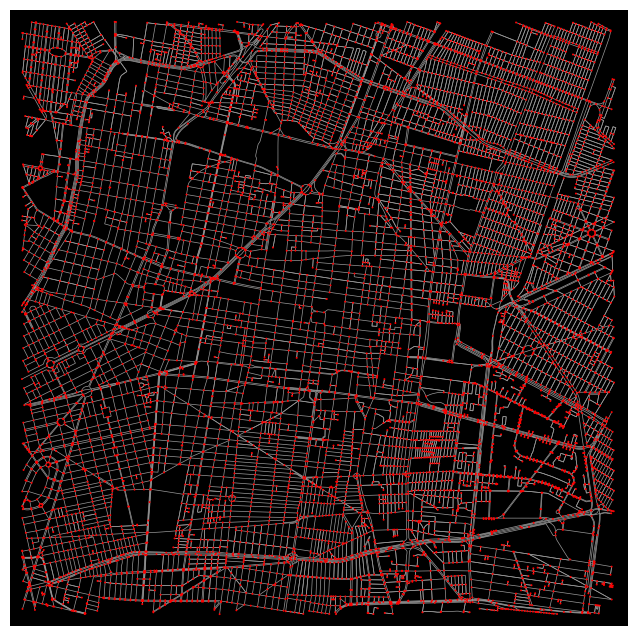

In [ ]:
# Renderizar el mapa base
fig, ax = ox.plot_graph(
    G, 
    node_size=2, 
    edge_linewidth=0.5, 
    node_color='red', 
    bgcolor='black'
)

In [ ]:
from collections import deque
import time

def bfs_rutas(grafo, origen, destino):
    tiempo_inicio = time.time()
    
    # Inicialización de estructuras
    frontera = deque([origen])
    visitados = {origen}
    padres = {origen: None}
    
    # Métricas requeridas
    nodos_expandidos = 0
    tamano_max_frontera = len(frontera)
    
    camino = []
    metros = 0.0
    arcos = 0
    
    while frontera:
        # Registrar el tamaño máximo que alcanza la cola
        if len(frontera) > tamano_max_frontera:
            tamano_max_frontera = len(frontera)
            
        nodo_actual = frontera.popleft()
        
        # Objetivo alcanzado
        if nodo_actual == destino:
            actual = destino
            while actual is not None:
                camino.append(actual)
                actual = padres[actual]
            camino.reverse()
            
            # Calcular las métricas de distancia del camino encontrado
            arcos = len(camino) - 1
            for i in range(arcos):
                u = camino[i]
                v = camino[i+1]
                # osmnx usa grafos múltiples; tomamos la primera arista [0]
                datos_arista = grafo[u][v][0] 
                metros += datos_arista.get('length', 0.0)
            break
            
        nodos_expandidos += 1
        
        # Expansión a vecinos
        for vecino in grafo.neighbors(nodo_actual):
            if vecino not in visitados:
                visitados.add(vecino)
                padres[vecino] = nodo_actual
                frontera.append(vecino)
                
    tiempo_ejecucion = (time.time() - tiempo_inicio) * 1000 # Conversión a milisegundos
    
    return {
        'camino': camino,
        'arcos': arcos,
        'metros': round(metros, 2),
        'nodos_expandidos': nodos_expandidos,
        'tamano_max_frontera': tamano_max_frontera,
        'tiempo_ejecucion_ms': round(tiempo_ejecucion, 2)
    }



In [ ]:
import random

def generar_pares_prueba(grafo, num_pares=5):
    nodos = list(grafo.nodes)
    pares = []
    for _ in range(num_pares):
        origen = random.choice(nodos)
        destino = random.choice(nodos)
        while destino == origen:
            destino = random.choice(nodos)
        pares.append((origen, destino))
    return pares

In [ ]:
# Generar nodos para probar
pares_prueba = generar_pares_prueba(G, 1)
origen_id, destino_id = pares_prueba[0]

print(f"Buscando ruta desde {origen_id} hasta {destino_id}...\n")

# Ejecutar la búsqueda BFS
resultados_bfs = bfs_rutas(G, origen_id, destino_id)

# Imprimir las métricas obtenidas
for metrica, valor in resultados_bfs.items():
    if metrica != 'camino': # Ocultamos la lista completa de nodos para no saturar la salida
        print(f"{metrica}: {valor}")

Buscando ruta desde 3639971455 hasta 274196207...

arcos: 76
metros: 8513.92
nodos_expandidos: 7957
tamano_max_frontera: 286
tiempo_ejecucion_ms: 5.27


In [ ]:
import time

def dfs_rutas(grafo, origen, destino):
    tiempo_inicio = time.time()
    
    # En DFS iterativo usamos una lista estándar pila (LIFO)
    frontera = [origen]
    visitados = {origen}
    padres = {origen: None}
    
    nodos_expandidos = 0
    tamano_max_frontera = len(frontera)
    
    camino = []
    metros = 0.0
    arcos = 0
    
    while frontera:
        if len(frontera) > tamano_max_frontera:
            tamano_max_frontera = len(frontera)
            
        # A diferencia de BFS (.popleft()), aquí sacamos el último elemento (.pop())
        nodo_actual = frontera.pop()
        
        if nodo_actual == destino:
            actual = destino
            while actual is not None:
                camino.append(actual)
                actual = padres[actual]
            camino.reverse()
            
            arcos = len(camino) - 1
            for i in range(arcos):
                u = camino[i]
                v = camino[i+1]
                datos_arista = grafo[u][v][0] 
                metros += datos_arista.get('length', 0.0)
            break
            
        nodos_expandidos += 1
        
        for vecino in grafo.neighbors(nodo_actual):
            if vecino not in visitados:
                visitados.add(vecino)
                padres[vecino] = nodo_actual
                frontera.append(vecino)
                
    tiempo_ejecucion = (time.time() - tiempo_inicio) * 1000
    
    return {
        'camino': camino,
        'arcos': arcos,
        'metros': round(metros, 2),
        'nodos_expandidos': nodos_expandidos,
        'tamano_max_frontera': tamano_max_frontera,
        'tiempo_ejecucion_ms': round(tiempo_ejecucion, 2)
    }

In [ ]:
print(f"Buscando ruta DFS desde {origen_id} hasta {destino_id}...\n")

# Ejecutar la búsqueda DFS
resultados_dfs = dfs_rutas(G, origen_id, destino_id)

# Imprimir las métricas obtenidas
for metrica, valor in resultados_dfs.items():
    if metrica != 'camino': 
        print(f"{metrica}: {valor}")

Buscando ruta DFS desde 3639971455 hasta 274196207...

arcos: 800
metros: 82588.99
nodos_expandidos: 8137
tamano_max_frontera: 1098
tiempo_ejecucion_ms: 6.13


In [ ]:
import heapq
import time

def ucs_rutas(grafo, origen, destino):
    tiempo_inicio = time.time()
    
    # Frontera como cola de prioridad (min-heap): almacena tuplas (costo_acumulado, nodo)
    frontera = [(0.0, origen)]
    # Diccionario para registrar el costo mínimo encontrado hacia cada nodo
    costos_explorados = {origen: 0.0}
    padres = {origen: None}
    
    nodos_expandidos = 0
    tamano_max_frontera = 1
    
    camino = []
    arcos = 0
    metros_totales = 0.0
    
    while frontera:
        if len(frontera) > tamano_max_frontera:
            tamano_max_frontera = len(frontera)
            
        # Extraer el nodo con el menor costo acumulado
        costo_actual, nodo_actual = heapq.heappop(frontera)
        
        # Objetivo alcanzado
        if nodo_actual == destino:
            actual = destino
            while actual is not None:
                camino.append(actual)
                actual = padres[actual]
            camino.reverse()
            
            arcos = len(camino) - 1
            metros_totales = costo_actual
            break
            
        # Ignorar si ya habíamos encontrado un camino más corto hacia este nodo extraído
        if costo_actual > costos_explorados.get(nodo_actual, float('inf')):
            continue
            
        nodos_expandidos += 1
        
        for vecino in grafo.neighbors(nodo_actual):
            datos_arista = grafo[nodo_actual][vecino][0]
            costo_arista = datos_arista.get('length', 0.0)
            nuevo_costo = costo_actual + costo_arista
            
            # Si encontramos un camino más barato hacia el vecino, lo registramos y lo encolamos
            if nuevo_costo < costos_explorados.get(vecino, float('inf')):
                costos_explorados[vecino] = nuevo_costo
                padres[vecino] = nodo_actual
                heapq.heappush(frontera, (nuevo_costo, vecino))
                
    tiempo_ejecucion = (time.time() - tiempo_inicio) * 1000 
    
    return {
        'camino': camino,
        'arcos': arcos,
        'metros': round(metros_totales, 2),
        'nodos_expandidos': nodos_expandidos,
        'tamano_max_frontera': tamano_max_frontera,
        'tiempo_ejecucion_ms': round(tiempo_ejecucion, 2)
    }

In [ ]:
print(f"Buscando ruta UCS desde {origen_id} hasta {destino_id}...\n")

# Ejecutar la búsqueda de Costo Uniforme (UCS)
resultados_ucs = ucs_rutas(G, origen_id, destino_id)

# Imprimir las métricas obtenidas
for metrica, valor in resultados_ucs.items():
    if metrica != 'camino':
        print(f"{metrica}: {valor}")

Buscando ruta UCS desde 3639971455 hasta 274196207...

arcos: 102
metros: 7471.51
nodos_expandidos: 5128
tamano_max_frontera: 131
tiempo_ejecucion_ms: 16.68


In [ ]:
import pandas as pd

# 1. Generar 5 pares de origen-destino distintos
pares_evaluacion = generar_pares_prueba(G, 5)
registro_metricas = []

print("Iniciando Evaluación...\n")

# 2. Iterar sobre cada par y ejecutar los 3 algoritmos
for i, (origen, destino) in enumerate(pares_evaluacion, 1):
    print(f"Procesando Instancia {i} (Origen: {origen} -> Destino: {destino})...")
    
    # Evaluar BFS
    res_bfs = bfs_rutas(G, origen, destino)
    res_bfs.update({'Algoritmo': 'BFS', 'Instancia': f'Par {i}'})
    registro_metricas.append(res_bfs)
    
    # Evaluar DFS
    res_dfs = dfs_rutas(G, origen, destino)
    res_dfs.update({'Algoritmo': 'DFS', 'Instancia': f'Par {i}'})
    registro_metricas.append(res_dfs)
    
    # Evaluar UCS
    res_ucs = ucs_rutas(G, origen, destino)
    res_ucs.update({'Algoritmo': 'UCS', 'Instancia': f'Par {i}'})
    registro_metricas.append(res_ucs)

# 3. Construye la tabla final excluyendo la lista de nodos del 'camino'
df_resultados = pd.DataFrame(registro_metricas)
columnas_ordenadas = [
    'Algoritmo', 'Instancia', 'nodos_expandidos', 
    'metros', 'arcos', 'tiempo_ejecucion_ms', 'tamano_max_frontera'
]
df_tabla = df_resultados[columnas_ordenadas]

print("\nEvaluación completada. Tabla comparativa:")
display(df_tabla)

Iniciando Evaluación...

Procesando Instancia 1 (Origen: 268840137 -> Destino: 268621340)...
Procesando Instancia 2 (Origen: 274187940 -> Destino: 271032670)...
Procesando Instancia 3 (Origen: 372177290 -> Destino: 274323482)...
Procesando Instancia 4 (Origen: 270286216 -> Destino: 270468242)...
Procesando Instancia 5 (Origen: 8246874939 -> Destino: 1404054284)...

Evaluación completada. Tabla comparativa:


,Algoritmo,Instancia,nodos_expandidos,metros,arcos,tiempo_ejecucion_ms,tamano_max_frontera
0,BFS,Par 1,2587,2633.21,35,2.49,196
1,DFS,Par 1,4905,177603.31,1741,7.58,1213
2,UCS,Par 1,1287,2633.21,35,5.31,127
3,BFS,Par 2,3878,4069.63,44,2.53,240
4,DFS,Par 2,3527,160075.26,1540,5.11,1127
5,UCS,Par 2,3507,3976.14,48,9.95,157
6,BFS,Par 3,6689,6948.35,55,6.32,286
7,DFS,Par 3,5168,144037.65,1402,8.10,1044
8,UCS,Par 3,5657,6592.91,67,17.94,143
9,BFS,Par 4,2067,4046.92,30,1.31,134


Generando snapshot para 100 expansiones...


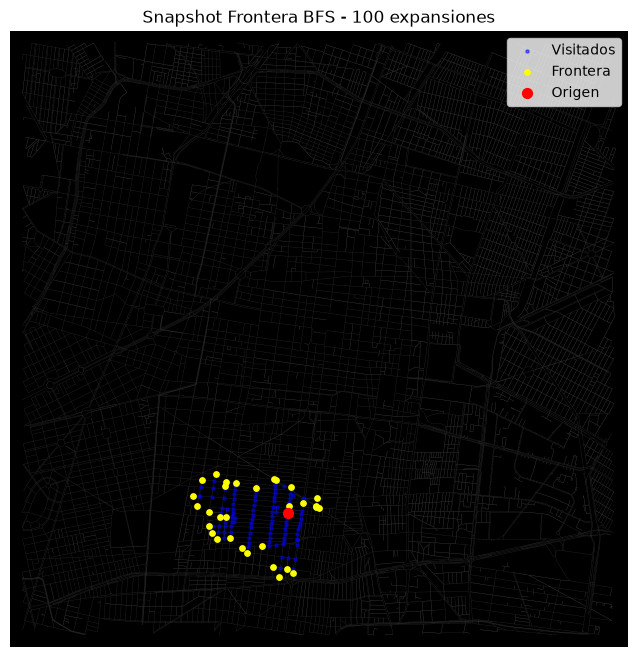

Generando snapshot para 500 expansiones...


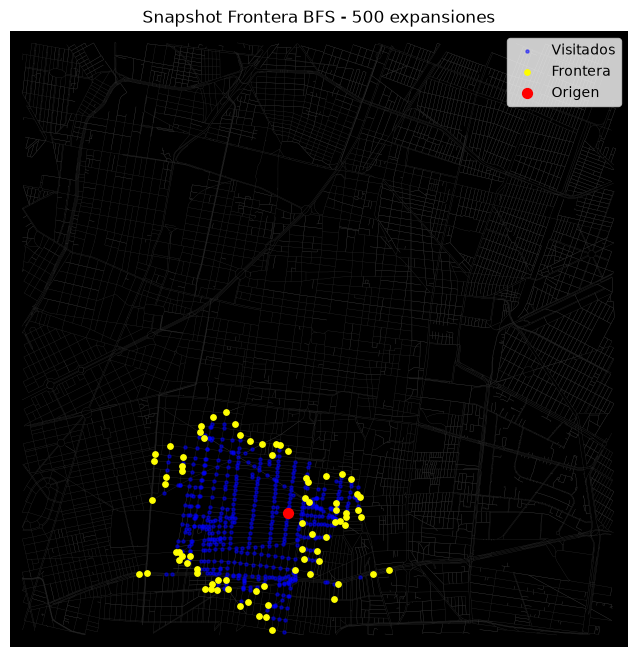

Generando snapshot para 1500 expansiones...


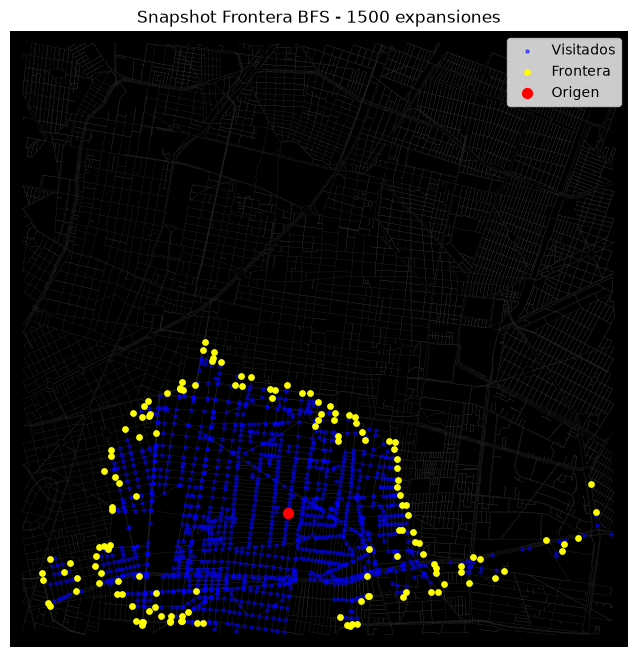

In [ ]:
import matplotlib.pyplot as plt
from collections import deque

def graficar_snapshot(grafo, origen, limite_expansiones):
    frontera = deque([origen])
    visitados = {origen}
    nodos_expandidos = 0
    
    # Ejecutar BFS parcialmente hasta el límite 
    while frontera and nodos_expandidos < limite_expansiones:
        nodo_actual = frontera.popleft()
        nodos_expandidos += 1
        
        for vecino in grafo.neighbors(nodo_actual):
            if vecino not in visitados:
                visitados.add(vecino)
                frontera.append(vecino)
                
    # 1. Preparar el mapa base de la ciudad
    fig, ax = ox.plot_graph(
        grafo, node_size=0, edge_linewidth=0.2, 
        edge_color='#333333', bgcolor='black', 
        show=False, close=False, figsize=(8,8)
    )
    
    # 2. Extraer las coordenadas geográficas (x, y) de los nodos
    vx = [grafo.nodes[n]['x'] for n in visitados]
    vy = [grafo.nodes[n]['y'] for n in visitados]
    fx = [grafo.nodes[n]['x'] for n in frontera]
    fy = [grafo.nodes[n]['y'] for n in frontera]
    
    # 3. Graficar los puntos sobre el mapa
    ax.scatter(vx, vy, c='blue', s=5, alpha=0.5, label='Visitados')
    ax.scatter(fx, fy, c='yellow', s=15, label='Frontera')
    ax.scatter([grafo.nodes[origen]['x']], [grafo.nodes[origen]['y']], c='red', s=50, label='Origen')
    
    plt.title(f"Snapshot Frontera BFS - {limite_expansiones} expansiones")
    plt.legend()
    plt.show()

# Tomar el origen del primer par de tu tabla para la demostración
origen_snapshot = pares_evaluacion[0][0]

# Generar los 3 snapshots obligatorios requeridos por la práctica
for iteraciones in [100, 500, 1500]:
    print(f"Generando snapshot para {iteraciones} expansiones...")
    graficar_snapshot(G, origen_snapshot, iteraciones)